In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

# Load Data

In [3]:
heart = pd.read_csv('DataSet/heart.csv')
# heart

# Understand the dataset attributes

In [4]:
print(f"Dataset shape: {heart.shape}")
print(f"\nData types:\n{heart.dtypes}")

Dataset shape: (303, 14)

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


Define column categories

In [5]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
target_col = "target"

Basic Statistics of the dataset

In [6]:
heart.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


# Preprocessing

Check missing values

In [7]:
nulls = heart.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found!")

No missing values found!


Check duplicates

In [8]:
heart[heart.duplicated(keep=False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [9]:
heart.drop_duplicates(inplace=True)
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


Detect outliers

Box plot

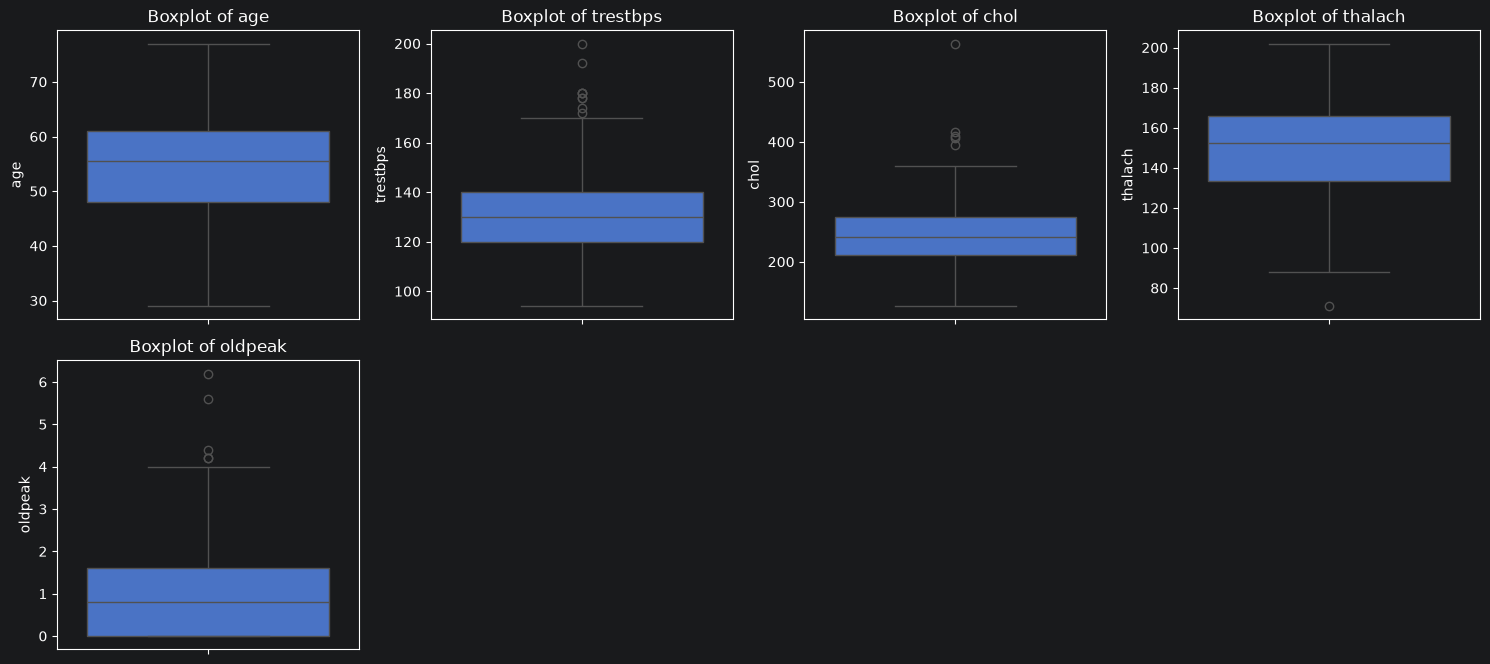

In [10]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=heart[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Replace outliers with limits

In [11]:
def outliers_iqr(df, columns):
    outlier_indices = []
    lower_limit = 0
    upper_limit = 0
    counter = 0
    print("Outlier (IQR method):")
    for col in columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        iqr = Q3 - Q1
        lower_limit = Q1 - 1.5 * iqr
        upper_limit = Q3 + 1.5 * iqr
        outliers = df[col][
            (df[col] < lower_limit) | (df[col] > upper_limit)
        ]

        print(f"\n{col}: {len(outliers)} outliers")
        if not outliers.empty:
            print(f"Values: {outliers.tolist()}")
            outlier_indices.extend(outliers.index)

        df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

        remaining_outliers = df[col][(df[col] < lower_limit) | (df[col] > upper_limit)]
        if (len(remaining_outliers) == 0):
            counter += 1

    print(f"\nTotal columns successfully cleared: {counter}/{len(columns)}")
    if (counter == len(columns)):
            print("All outliers replaced")

    return df

heart = outliers_iqr(heart, numerical_cols)

Outlier (IQR method):

age: 0 outliers

trestbps: 9 outliers
Values: [172, 178, 180, 180, 200, 174, 192, 178, 180]

chol: 5 outliers
Values: [417, 564, 394, 407, 409]

thalach: 1 outliers
Values: [71]

oldpeak: 5 outliers
Values: [4.2, 6.2, 5.6, 4.2, 4.4]

Total columns successfully cleared: 5/5
All outliers replaced


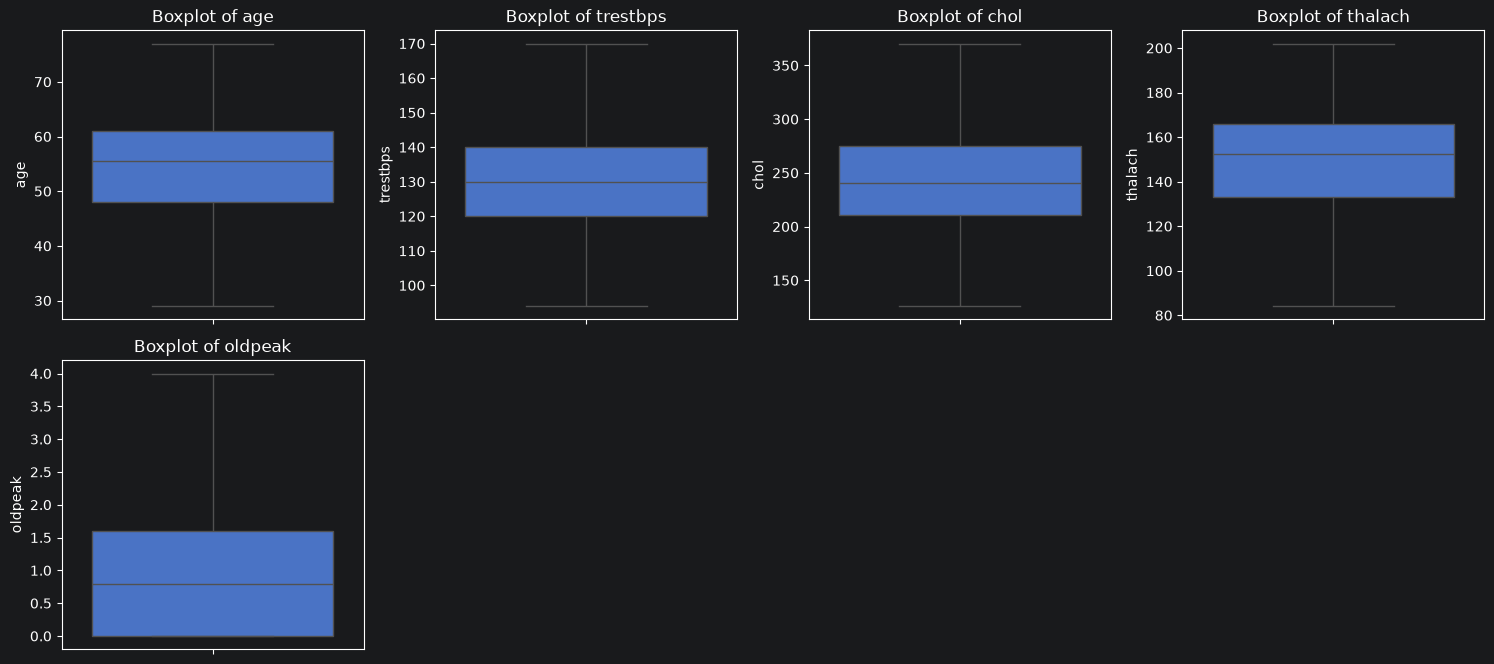

In [12]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=heart[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Correlation relations between variables

Correlation matrix

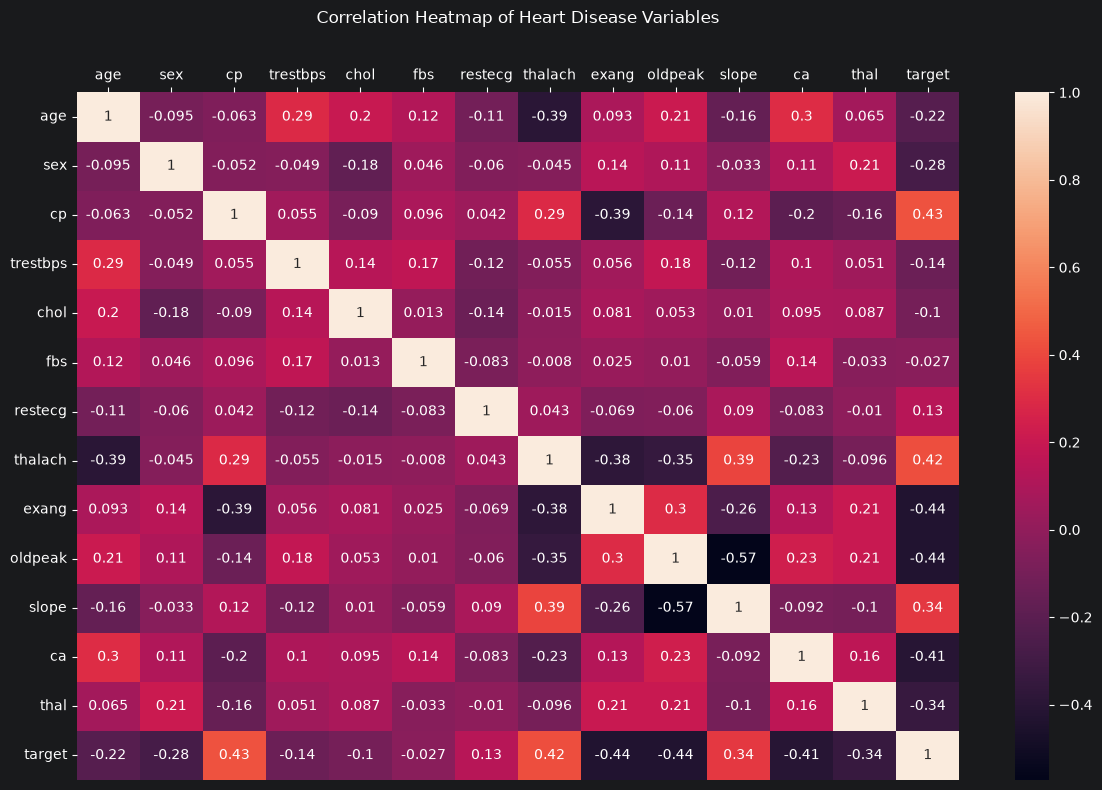

In [13]:
corr_matrix = heart.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap of Heart Disease Variables", pad=50)
plt.gca().xaxis.tick_top()
plt.tight_layout()
plt.show()

Heart disease Distribution in the dataset

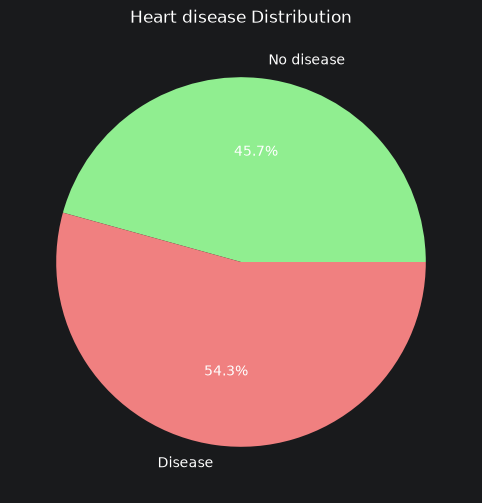

In [14]:
plt.figure(figsize=(8, 6))
count = heart['target'].value_counts().sort_index()
plt.pie(count.values, labels=['No disease ', 'Disease'],
        autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
plt.title('Heart disease Distribution')
plt.show()

Correlation coefficient between each feature and target

In [15]:
print("Correlation with Target Variable:")
print(corr_matrix["target"].sort_values(ascending=False), "\n")
print("correlation coff. (]0, 1] -> Direct relation), ([-1, 0[ -> Inverse relation), (0 -> No relation)")

Correlation with Target Variable:
target      1.000000
cp          0.432080
thalach     0.420408
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.099932
trestbps   -0.140083
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.435099
exang      -0.435601
Name: target, dtype: float64 

correlation coff. (]0, 1] -> Direct relation), ([-1, 0[ -> Inverse relation), (0 -> No relation)


Distribution of most two features by Heart disease

C:\Users\mm671\AppData\Local\Temp\ipykernel_68212\3621336620.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(['No disease', 'disease'])
C:\Users\mm671\AppData\Local\Temp\ipykernel_68212\3621336620.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(['No disease', 'disease'])


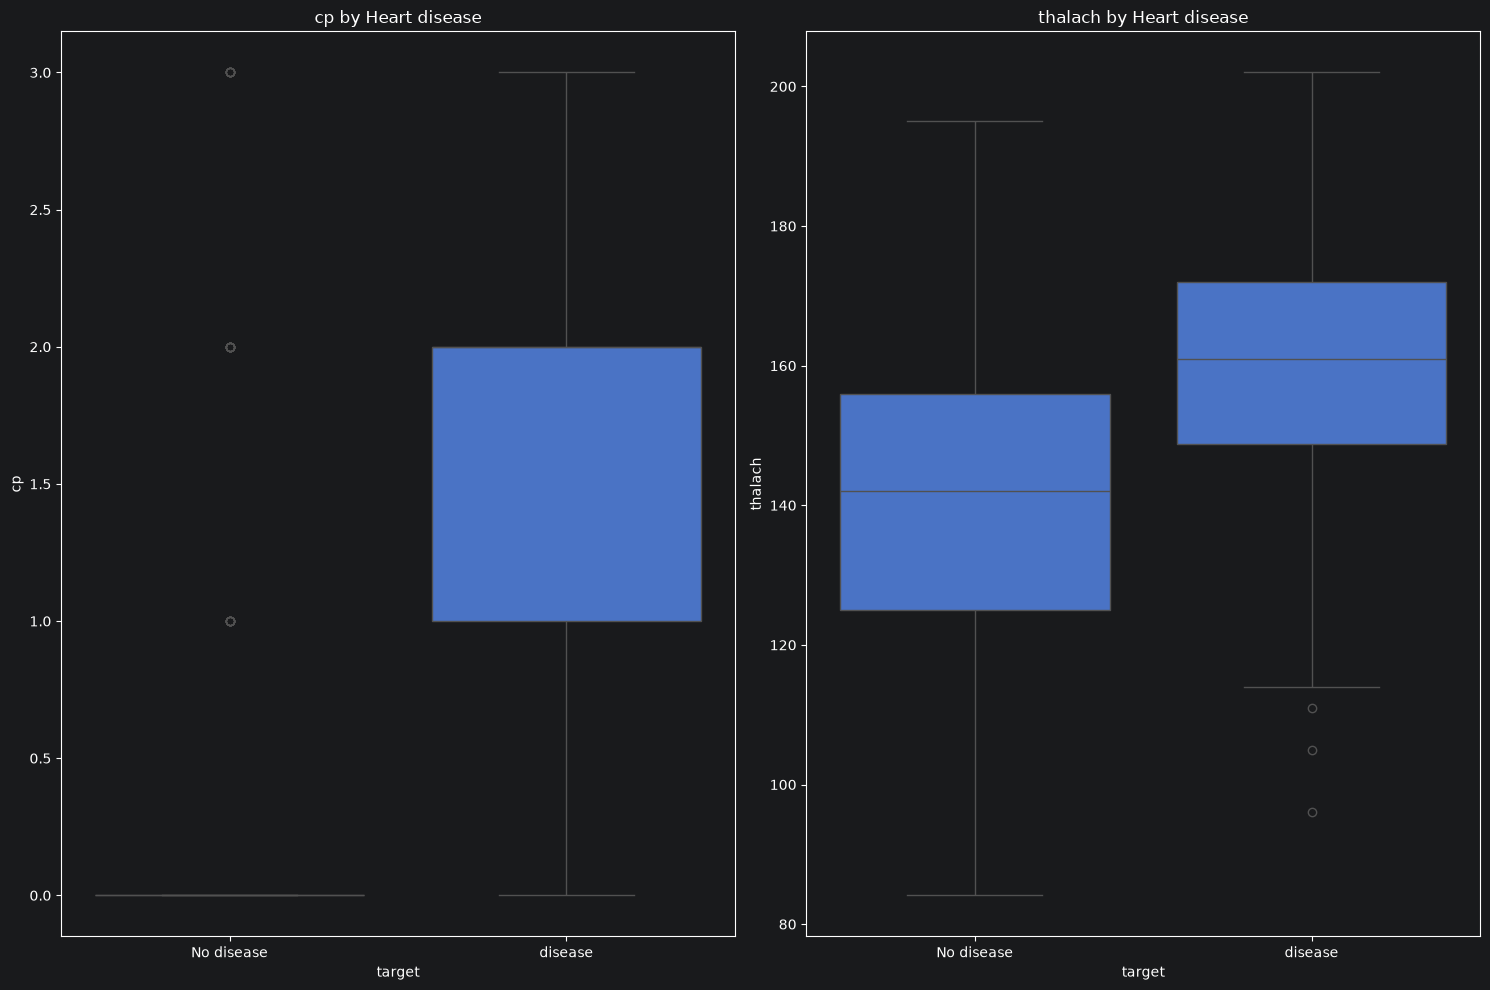

In [16]:
key_features = ['cp', 'thalach']
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    sns.boxplot(x='target', y=feature, data=heart, ax=axes[i])
    axes[i].set_title(f'{feature} by Heart disease')
    axes[i].set_xticklabels(['No disease', 'disease'])

plt.tight_layout()
plt.show()

## Graphs

Gender based analysis

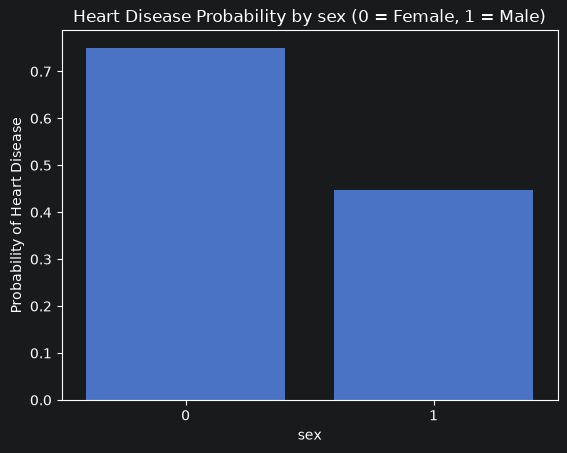

Percentage of Females with heart disease: 75.00%
Percentage of Males with heart disease: 44.66%


In [17]:
sns.barplot(x='sex', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by sex (0 = Female, 1 = Male)")
plt.ylabel("Probability of Heart Disease")
plt.show()

# Calculate exact percentages
rates = heart.groupby('sex')['target'].mean() * 100
print(f"Percentage of Females with heart disease: {rates[0]:.2f}%")
print(f"Percentage of Males with heart disease: {rates[1]:.2f}%")

Age based analysis

Descretization

In [18]:
bins = [0, 40, 55, 100]
labels = ['Young (<40)', 'Middle-Aged (40-55)', 'Senior (55+)']
heart['age_group'] = pd.cut(heart['age'], bins=bins, labels=labels)

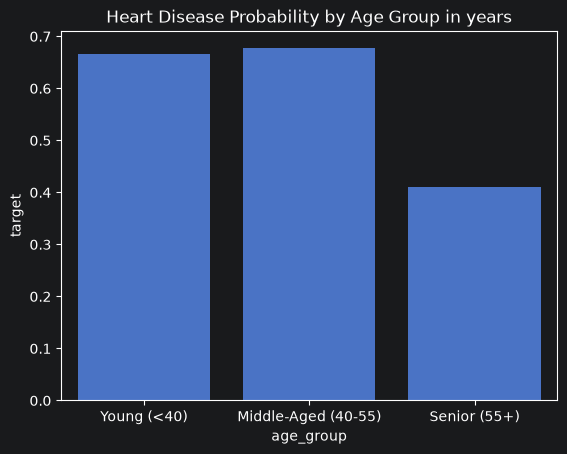


Percentage of diagnosed people by age group with heart disease:
age_group
Young (<40)            66.666667
Middle-Aged (40-55)    67.669173
Senior (55+)           41.059603
Name: target, dtype: float64


In [19]:
sns.barplot(x='age_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by Age Group in years")
plt.show()

# Calculate exact percentages
rates = heart.groupby('age_group')['target'].mean() * 100
print("\nPercentage of diagnosed people by age group with heart disease:")
print(rates)

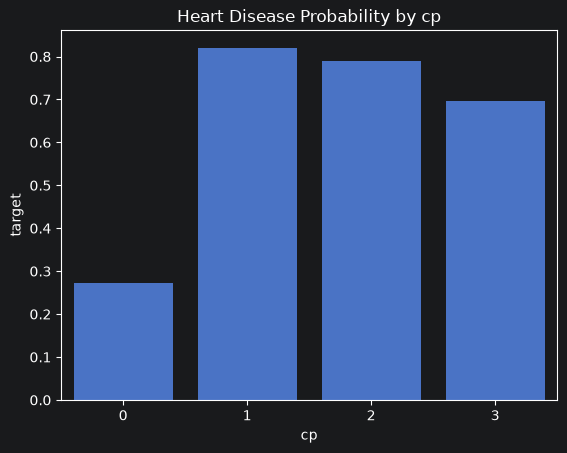

Percentage of chest pain type 0 with heart disease: 27.27%
Percentage of chest pain type 1 with heart disease: 82.00%
Percentage of chest pain type 2 with heart disease: 79.07%
Percentage of chest pain type 3 with heart disease: 69.57%


In [20]:
sns.barplot(x='cp', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by cp")
plt.show()

# Calculate exact percentages
rates = heart.groupby('cp')['target'].mean() * 100
for i in [0,1,2,3]:
    print(f"Percentage of chest pain type {i} with heart disease: {rates[i]:.2f}%")

In [21]:
bins = [90, 110, 160, 200]
labels = ['low (<110)', 'Normal (110-160)', 'high (160+)']
heart['trestbps_group'] = pd.cut(heart['trestbps'], bins=bins, labels=labels)

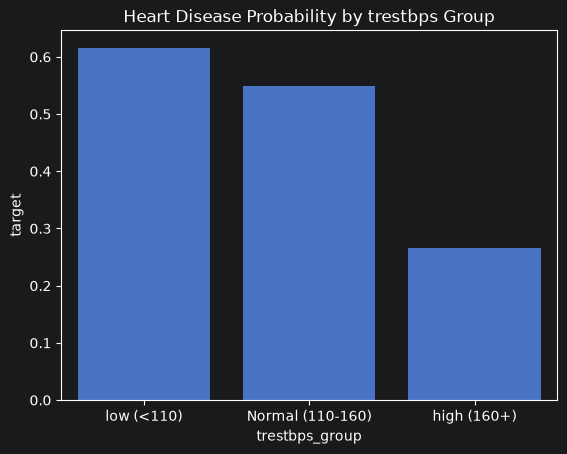


Percentage of diagnosed people by trestbps group with heart disease:
trestbps_group
low (<110)          61.538462
Normal (110-160)    54.838710
high (160+)         26.666667
Name: target, dtype: float64


In [22]:
sns.barplot(x='trestbps_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by trestbps Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('trestbps_group')['target'].mean() * 100
print("\nPercentage of diagnosed people by trestbps group with heart disease:")
print(rates)

In [23]:
bins = [125, 250, 400, 550]
labels = ['(125 - 250)', '(250-400)', 'high (400 - 550)']
heart['chol_group'] = pd.cut(heart['chol'], bins=bins, labels=labels)

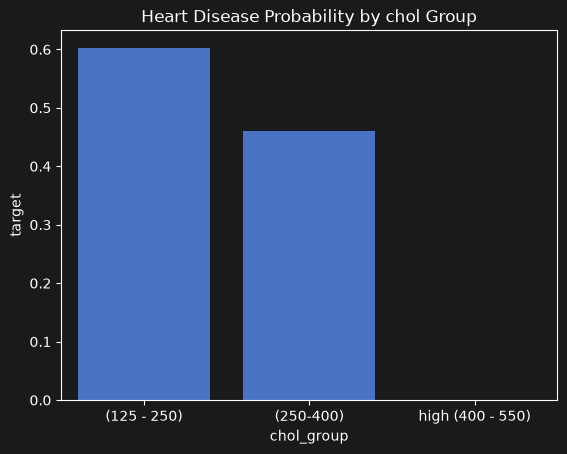


Percentage of chol Group with heart disease:
chol_group
(125 - 250)    60.227273
(250-400)      46.031746
Name: target, dtype: float64


In [24]:
sns.barplot(x='chol_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by chol Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('chol_group')['target'].mean() * 100
print("\nPercentage of chol Group with heart disease:")
print(rates)

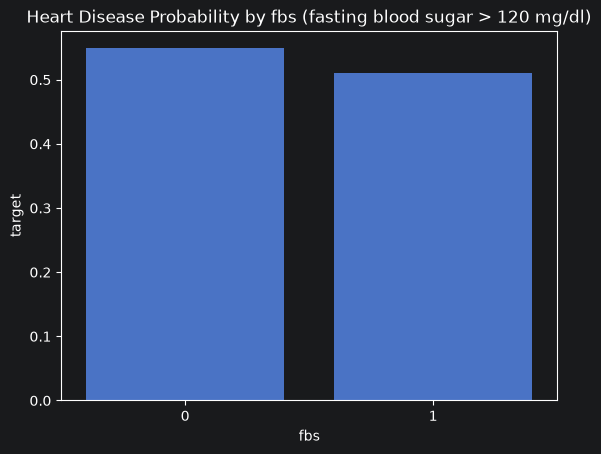

Percentage of < 120 mg/dl with heart disease: 54.86%
Percentage of > 120 mg/dl with heart disease: 51.11%


In [25]:
sns.barplot(x='fbs', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by fbs (fasting blood sugar > 120 mg/dl)")
plt.show()

# Calculate exact percentages
rates = heart.groupby('fbs')['target'].mean() * 100
print(f"Percentage of < 120 mg/dl with heart disease: {rates[0]:.2f}%")
print(f"Percentage of > 120 mg/dl with heart disease: {rates[1]:.2f}%")

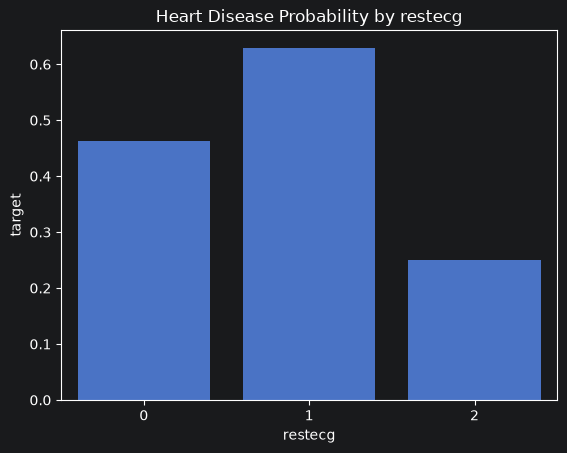

Percentage of Resting ECG type 0 with heart disease: 46.26%
Percentage of Resting ECG type 1 with heart disease: 62.91%
Percentage of Resting ECG type 2 with heart disease: 25.00%


In [26]:
sns.barplot(x='restecg', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by restecg")
plt.show()

# Calculate exact percentages
rates = heart.groupby('restecg')['target'].mean() * 100
for i in [0,1,2]:
    print(f"Percentage of Resting ECG type {i} with heart disease: {rates[i]:.2f}%")

In [27]:
bins = [70, 110, 160, 210]
labels = ['(70 - 110)', '(110-160)', '(160 - 210)']
heart['thalach_group'] = pd.cut(heart['thalach'], bins=bins, labels=labels)

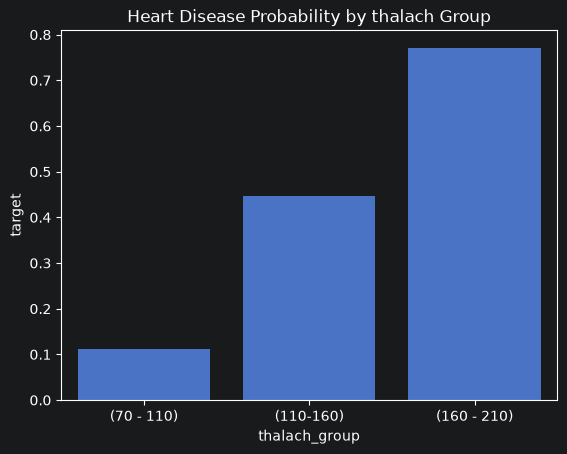


Percentage of diagnosed people by thalach group with heart disease:
thalach_group
(70 - 110)     11.111111
(110-160)      44.571429
(160 - 210)    77.064220
Name: target, dtype: float64


In [28]:
sns.barplot(x='thalach_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by thalach Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('thalach_group')['target'].mean() * 100
print("\nPercentage of diagnosed people by thalach group with heart disease:")
print(rates)

In [29]:
bins = [0, 2, 4, 7]
labels = ['(0 - 2)', '(2-4)', '(4 - 7)']
heart['oldpeak_group'] = pd.cut(heart['oldpeak'], bins=bins, labels=labels, include_lowest=True)

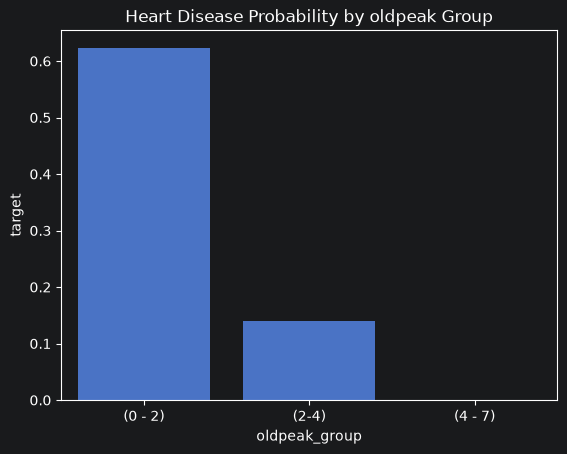


Percentage of oldpeak with heart disease:
oldpeak_group
(0 - 2)    62.301587
(2-4)      14.000000
Name: target, dtype: float64


In [30]:
sns.barplot(x='oldpeak_group', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by oldpeak Group")
plt.show()

# Calculate exact percentages
rates = heart.groupby('oldpeak_group')['target'].mean() * 100
print("\nPercentage of oldpeak with heart disease:")
print(rates)

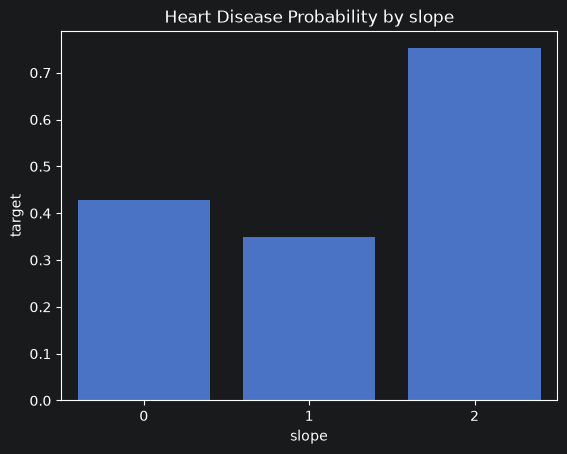

Percentage of Slope of peak exercise ST segment 0 with heart disease: 42.86%
Percentage of Slope of peak exercise ST segment 1 with heart disease: 35.00%
Percentage of Slope of peak exercise ST segment 2 with heart disease: 75.18%


In [31]:
sns.barplot(x='slope', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by slope")
plt.show()

# Calculate exact percentages
rates = heart.groupby('slope')['target'].mean() * 100
for i in [0,1,2]:
    print(f"Percentage of Slope of peak exercise ST segment {i} with heart disease: {rates[i]:.2f}%")

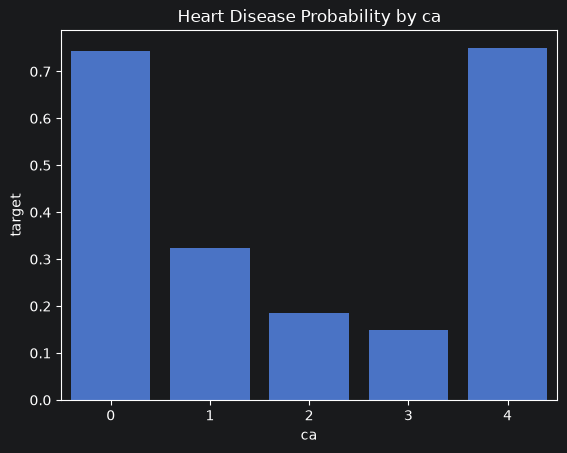

Percentage of ca type 0 with heart disease: 74.29%
Percentage of ca type 1 with heart disease: 32.31%
Percentage of ca type 2 with heart disease: 18.42%
Percentage of ca type 3 with heart disease: 15.00%


In [32]:
sns.barplot(x='ca', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by ca")
plt.show()

# Calculate exact percentages
rates = heart.groupby('ca')['target'].mean() * 100
for i in [0,1,2,3]:
    print(f"Percentage of ca type {i} with heart disease: {rates[i]:.2f}%")

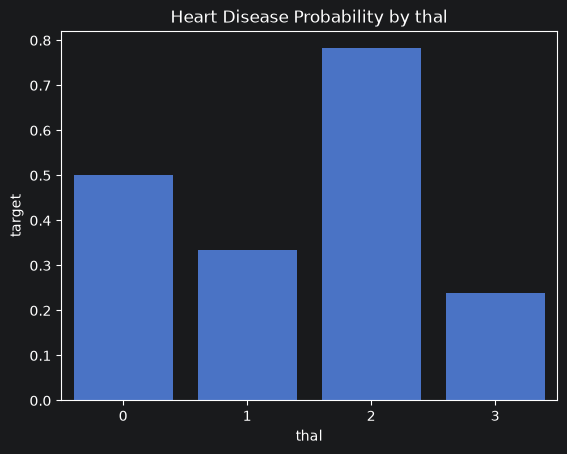

Percentage of thal type: 0 with heart disease: 50.00%
Percentage of thal type: 1 with heart disease: 33.33%
Percentage of thal type: 2 with heart disease: 78.18%


In [33]:
sns.barplot(x='thal', y='target', data=heart, errorbar=None)
plt.title("Heart Disease Probability by thal")
plt.show()

# Calculate exact percentages
rates = heart.groupby('thal')['target'].mean() * 100
for i in [0,1,2]:
    print(f"Percentage of thal type: {i} with heart disease: {rates[i]:.2f}%")

# Preprocessing and Data splitting

In [34]:
#heart

In [35]:
# Drop the categorical binned columns created during EDA to avoid multicollinearity
columns_to_drop = ['age_group', 'trestbps_group', 'chol_group', 'thalach_group', 'oldpeak_group']
heart_model = heart.drop(columns=[col for col in columns_to_drop if col in heart.columns], errors='ignore')
# Drop numerical data and make another dataframe with categorical data instead
heart_model_cat = heart.drop(columns=[col for col in numerical_cols if col in heart.columns], errors='ignore')

In [36]:
# Separate features (X) and target (y)
X = heart_model.drop(columns=[target_col])
X_cat = heart_model_cat.drop(columns=[target_col])
y = heart_model[target_col]

In [37]:
# One-hot encoding for categorical variables (dropping first to avoid dummy variable trap)
encoding_cols = ['cp', 'restecg', 'slope', 'thal']
X = pd.get_dummies(X, columns=encoding_cols, drop_first=True)
X_cat = pd.get_dummies(X_cat, columns=encoding_cols, drop_first=True)

In [38]:
# TRAIN / TEST SPLIT (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y, test_size=0.2, random_state=42, stratify=y)

Normalization

In [39]:
normalizer = MinMaxScaler(feature_range=(0, 1))
X_train[numerical_cols] = normalizer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = normalizer.transform(X_test[numerical_cols])
print(X_train[numerical_cols])

          age  trestbps      chol   thalach  oldpeak
59   0.583333  0.447368  0.724297  0.622807     0.00
247  0.770833  0.868421  0.491049  0.280702     0.00
289  0.541667  0.447368  0.323274  0.368421     0.50
288  0.583333  0.210526  0.855243  0.482456     0.75
64   0.604167  0.605263  0.347826  0.675439     0.00
..        ...       ...       ...       ...      ...
39   0.750000  0.868421  0.957545  0.552632     0.20
115  0.166667  0.342105  0.364194  0.719298     0.00
139  0.729167  0.447368  0.560614  0.149123     0.05
163  0.187500  0.578947  0.200512  0.745614     0.00
149  0.270833  0.473684  0.220972  0.543860     0.00

[241 rows x 5 columns]


# KNN

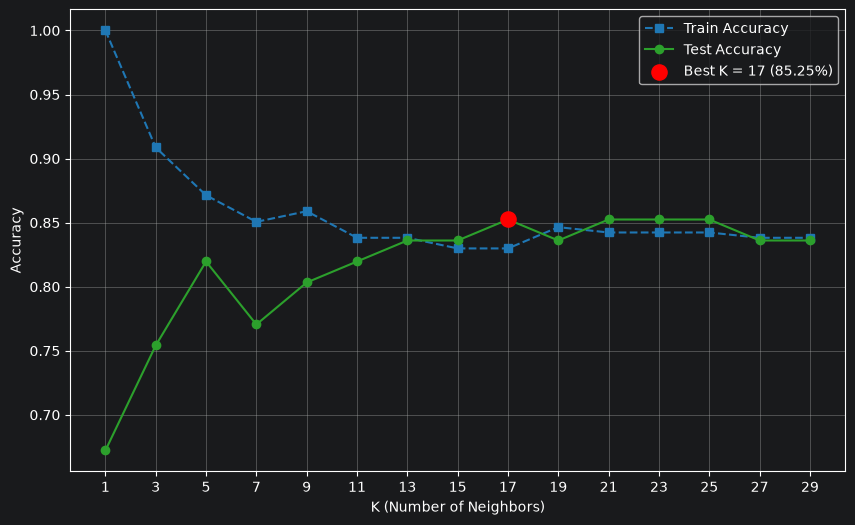

In [40]:
k_range = list(range(1, 31, 2))
train_accuracies = []
test_accuracies = []

for k in k_range:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
  test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

best_k = k_range[test_accuracies.index(max(test_accuracies))]
best_acc = max(test_accuracies)

plt.figure(figsize=(10, 6))
plt.plot(k_range,train_accuracies,label='Train Accuracy',marker='s',linestyle='--',color='#1f77b4')
plt.plot(k_range,test_accuracies,label='Test Accuracy',marker='o',color='#2ca02c')
plt.scatter(best_k, best_acc, color='red', s=120, zorder=5, label=f'Best K = {best_k} ({best_acc:.2%})')

plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.grid()
plt.legend()
plt.show()

In [41]:
knn_model = KNeighborsClassifier(n_neighbors=17)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Confusion Matrix:
[[23  5]
 [ 4 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        28
           1       0.85      0.88      0.87        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



# Decision tree

In [42]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Confusion Matrix:
[[18 10]
 [ 4 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.64      0.72        28
           1       0.74      0.88      0.81        33

    accuracy                           0.77        61
   macro avg       0.78      0.76      0.76        61
weighted avg       0.78      0.77      0.77        61



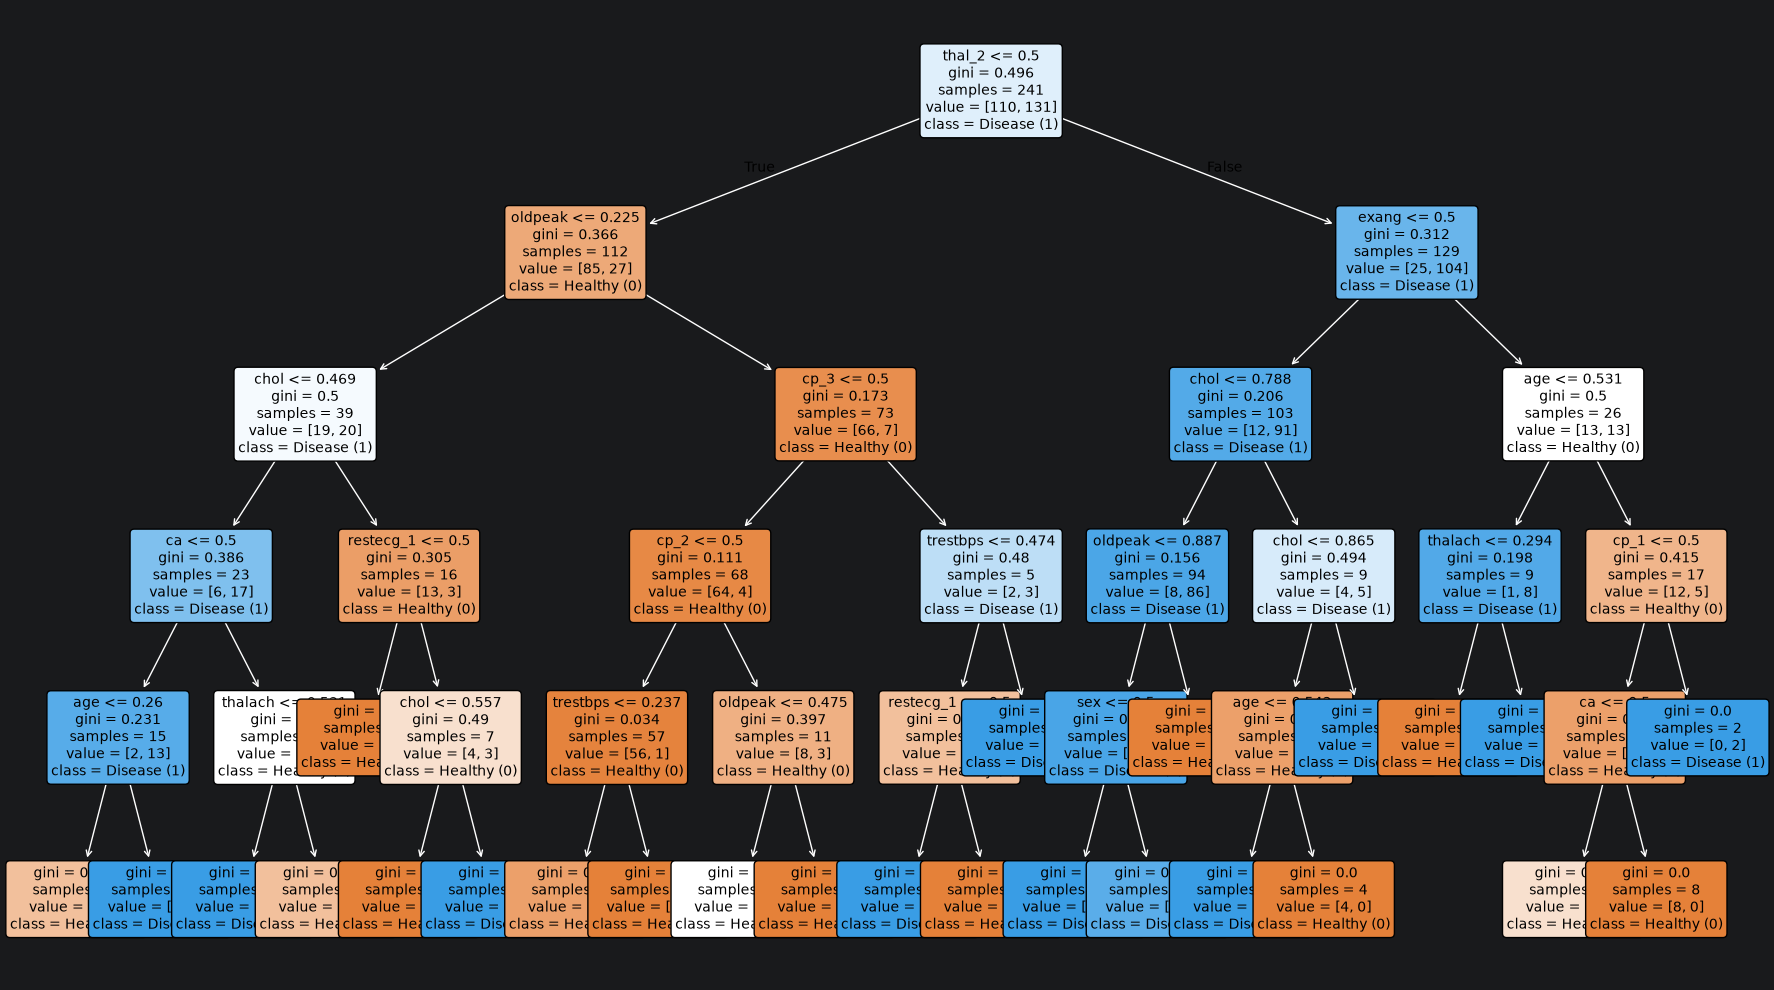

In [54]:
plt.figure(figsize=(18, 10))
annotations = plot_tree(dt_model,feature_names=X_train.columns, class_names=['Healthy (0)', 'Disease (1)'],filled=True,rounded=True,fontsize=10)
for text in annotations:
  text.set_color('black')

plt.tight_layout()
plt.savefig('decision_tree.png')
plt.show()

# Logistic regression

In [45]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[20  8]
 [ 2 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80        28
           1       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



# Naive Bayes

In [46]:
encoder = OrdinalEncoder()
X_encoded_full = encoder.fit_transform(X_cat.astype(str))

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded_full, y, test_size=0.2, random_state=42, stratify=y
)

In [51]:
nb = CategoricalNB()
nb.fit(X_train_enc, y_train_enc)

y_pred_nb = nb.predict(X_test_enc)

print("Confusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_nb))

Confusion Matrix:
[[24  4]
 [ 7 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81        28
           1       0.87      0.79      0.83        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



Accuracy Comparision 

In [53]:
comparison_data = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
    },
    {"Model": "KNN", "Accuracy": accuracy_score(y_test, y_pred_knn)},
    {"Model": "Decision Tree", "Accuracy": accuracy_score(y_test, y_pred_dt)},
    {"Model": "Naïve Bayes", "Accuracy": accuracy_score(y_test_enc, y_pred_nb)},
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy
0,KNN,0.852459
1,Logistic Regression,0.836066
2,Naïve Bayes,0.819672
3,Decision Tree,0.770492
